In [13]:
!pip install numpy pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [15]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [17]:
# Load raw data
df = pd.read_csv('../data/raw/house_price.csv')
print("✅ Raw dataset loaded")
print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Target : Saleprice | min={df['Saleprice'].min():,.0f} | "
      f"median={df['Saleprice'].median():,.0f} | max={df['Saleprice'].max():,.0f}")
df.head()

✅ Raw dataset loaded
   Shape : 1458 rows × 380 columns
   Target : Saleprice | min=34,901 | median=163,001 | max=755,001


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,...,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2006,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Saleprice
0,1,18.14,13.83,7,3.99,2003,2003,19.43,144.12,0.00,29.99,422.49,5.94,1025.65,0.00,8.35,0.99,0.00,2,1.07,3,0.75,2.26,0.00,2003.00,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,208501.00
1,2,20.67,14.12,6,6.00,1976,1976,54.60,181.72,0.00,44.14,593.89,6.23,665.14,0.00,7.97,0.00,0.71,2,0.00,3,0.75,2.00,0.90,1976.00,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,181501.00
2,3,18.67,14.48,7,3.99,2001,2002,17.77,110.44,0.00,56.90,450.08,5.99,1040.52,0.00,8.41,0.99,0.00,2,1.07,3,0.75,2.00,0.90,2001.00,...,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,223501.00
3,4,17.25,14.11,7,3.99,1915,1970,54.60,61.80,0.00,64.81,378.85,6.03,904.48,0.00,8.36,0.99,0.00,1,0.00,3,0.75,2.14,0.90,1998.00,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,140001.00
4,5,21.31,15.02,8,3.99,2000,2000,25.40,136.62,0.00,61.17,545.31,6.16,1273.02,0.00,8.67,0.99,0.00,2,1.07,4,0.75,2.37,0.90,2000.00,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,250001.00


In [12]:
# Baseline audit
print("=" * 55)
print("BASELINE AUDIT")
print("=" * 55)
 
# Missing values
total_missing = df.isnull().sum().sum()
print(f"\n[1] Missing values     : {total_missing}")
 
# Duplicates
dup_rows = df.duplicated().sum()
dup_ids  = df['Id'].duplicated().sum()
print(f"[2] Duplicate rows     : {dup_rows}")
print(f"[3] Duplicate Id vals  : {dup_ids}")
 
# Constant columns
const_cols = [c for c in df.columns if df[c].nunique() <= 1]
print(f"[4] Constant columns   : {len(const_cols)} → {const_cols}")
 
# Near-constant columns (≥99% one value)
near_const_cols = [
    c for c in df.columns
    if df[c].value_counts(normalize=True).iloc[0] >= 0.99
]
print(f"[5] Near-constant cols : {len(near_const_cols)} (≥99% same value)")
print(f"\nRaw shape              : {df.shape}")

BASELINE AUDIT

[1] Missing values     : 0
[2] Duplicate rows     : 0
[3] Duplicate Id vals  : 0
[4] Constant columns   : 4 → ['has2ndfloor', 'hasgarage', 'hasbsmt', 'MSSubClass_150']
[5] Near-constant cols : 90 (≥99% same value)

Raw shape              : (1458, 380)


In [22]:
# Step 1: Drop fully constant columns
CONSTANT_COLS = [c for c in df.columns if df[c].nunique() <= 1]
 
df.drop(columns=CONSTANT_COLS, inplace=True)
 
print(f"✅ Step 1 — Dropped {len(CONSTANT_COLS)} constant columns")
print(f"   {CONSTANT_COLS}")
print(f"   Shape now : {df.shape}")

✅ Step 1 — Dropped 0 constant columns
   []
   Shape now : (1458, 290)


In [23]:
# Step 2: Drop near-constant columns (≥99% one value)

near_const_cols = [
    c for c in df.columns
    if df[c].value_counts(normalize=True).iloc[0] >= 0.99
]
 
df.drop(columns=near_const_cols, inplace=True)
 
print(f"✅ Step 2 — Dropped {len(near_const_cols)} near-constant columns (≥99% same value)")
print(f"   Shape now : {df.shape}")

✅ Step 2 — Dropped 1 near-constant columns (≥99% same value)
   Shape now : (1458, 289)


In [24]:
# Step 3: Drop redundant engineered feature
# TotalSF and Total_sqr_footage are 95% correlated — keep TotalSF

if 'Total_sqr_footage' in df.columns:
    df.drop(columns=['Total_sqr_footage'], inplace=True)
    print("✅ Step 3 — Dropped 'Total_sqr_footage' (r=0.95 with TotalSF)")
else:
    print("ℹ️  Step 3 — 'Total_sqr_footage' already removed")
 
print(f"   Shape now : {df.shape}")

ℹ️  Step 3 — 'Total_sqr_footage' already removed
   Shape now : (1458, 289)


In [25]:
# Step 4: Flag Saleprice outliers (do NOT drop)

Q1 = df['Saleprice'].quantile(0.25)
Q3 = df['Saleprice'].quantile(0.75)
IQR = Q3 - Q1
luxury_threshold = Q3 + 3 * IQR
 
df['is_luxury'] = (df['Saleprice'] > luxury_threshold).astype(int)
 
luxury_count = df['is_luxury'].sum()
print(f"✅ Step 4 — Flagged {luxury_count} luxury outliers as is_luxury=1")
print(f"   Threshold : ${luxury_threshold:,.0f}")
print(f"   These are legitimate high-quality homes (OverallQual 8–10) — NOT dropped")
 
df[df['is_luxury'] == 1][['Id', 'OverallQual', 'Saleprice']].sort_values('Saleprice')
 

✅ Step 4 — Flagged 12 luxury outliers as is_luxury=1
   Threshold : $466,226
   These are legitimate high-quality homes (OverallQual 8–10) — NOT dropped


/var/folders/21/z21b19xd5_g1_h61mdxcdyrh0000gn/T/ipykernel_18627/603689391.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_luxury'] = (df['Saleprice'] > luxury_threshold).astype(int)


,Id,OverallQual,Saleprice
1371,1372,10,466501.00
185,186,10,475001.00
797,798,9,485001.00
178,179,9,501838.00
768,769,8,538001.00
440,441,10,555001.00
1045,1046,9,556582.00
802,803,9,582934.00
897,898,9,611658.00
1168,1169,10,625001.00


In [26]:
# Step 5: Add financial crisis year flag
crisis_cols = [c for c in df.columns if c in ['YrSold_2008', 'YrSold_2009']]
 
if crisis_cols:
    df['is_crisis_year'] = df[crisis_cols].max(axis=1).astype(int)
    print(f"✅ Step 5 — Added 'is_crisis_year' flag from {crisis_cols}")
    print(f"   Crisis year rows : {df['is_crisis_year'].sum()}")
else:
    # Fallback if YrSold exists as a raw column
    if 'YrSold' in df.columns:
        df['is_crisis_year'] = df['YrSold'].isin([2008, 2009]).astype(int)
        print(f"✅ Step 5 — Added 'is_crisis_year' flag from YrSold column")
    else:
        print("ℹ️  Step 5 — No YrSold column found, skipping crisis flag")
 
print(f"   Shape now : {df.shape}")

✅ Step 5 — Added 'is_crisis_year' flag from ['YrSold_2008', 'YrSold_2009']
   Crisis year rows : 641
   Shape now : (1458, 291)


/var/folders/21/z21b19xd5_g1_h61mdxcdyrh0000gn/T/ipykernel_18627/3454257647.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_crisis_year'] = df[crisis_cols].max(axis=1).astype(int)


In [27]:
# Step 6: Drop Id from analytical views
        #    (keep in df for row lookup, exclude from corr/model)
# We do NOT drop Id from df — we just exclude it during analysis
EXCLUDE_FROM_ANALYSIS = ['Id', 'is_luxury', 'is_crisis_year']
 
print("ℹ️  Step 6 — Id retained in DataFrame for row lookup")
print(f"   Always exclude from correlation / modelling: {EXCLUDE_FROM_ANALYSIS}")
 

ℹ️  Step 6 — Id retained in DataFrame for row lookup
   Always exclude from correlation / modelling: ['Id', 'is_luxury', 'is_crisis_year']


In [29]:
# Final cleaned dataset summary

print("=" * 55)
print("CLEANED DATASET SUMMARY")
print("=" * 55)
print(f"  Rows              : {df.shape[0]}")
print(f"  Columns           : {df.shape[1]}")
print(f"  Missing values    : {df.isnull().sum().sum()}")
print(f"  Duplicate rows    : {df.duplicated().sum()}")
print(f"  Luxury properties : {df['is_luxury'].sum()} flagged (is_luxury=1)")
print(f"  Crisis year rows  : {df['is_crisis_year'].sum()} flagged (is_crisis_year=1)")
print(f"\n  Saleprice stats:")
print(f"    Min    : ${df['Saleprice'].min():,.0f}")
print(f"    Median : ${df['Saleprice'].median():,.0f}")
print(f"    Mean   : ${df['Saleprice'].mean():,.0f}")
print(f"    Max    : ${df['Saleprice'].max():,.0f}")
df.head()

CLEANED DATASET SUMMARY
  Rows              : 1458
  Columns           : 291
  Missing values    : 0
  Duplicate rows    : 0
  Luxury properties : 12 flagged (is_luxury=1)
  Crisis year rows  : 641 flagged (is_crisis_year=1)

  Saleprice stats:
    Min    : $34,901
    Median : $163,001
    Mean   : $180,934
    Max    : $755,001


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,...,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2006,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_COD,SaleType_New,SaleType_WD,SaleCondition_Abnorml,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Saleprice,is_luxury,is_crisis_year
0,1,18.14,13.83,7,3.99,2003,2003,19.43,144.12,0.00,29.99,422.49,5.94,1025.65,0.00,8.35,0.99,0.00,2,1.07,3,0.75,2.26,0.00,2003.00,...,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,208501.00,0,1
1,2,20.67,14.12,6,6.00,1976,1976,54.60,181.72,0.00,44.14,593.89,6.23,665.14,0.00,7.97,0.00,0.71,2,0.00,3,0.75,2.00,0.90,1976.00,...,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,181501.00,0,0
2,3,18.67,14.48,7,3.99,2001,2002,17.77,110.44,0.00,56.90,450.08,5.99,1040.52,0.00,8.41,0.99,0.00,2,1.07,3,0.75,2.00,0.90,2001.00,...,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,223501.00,0,1
3,4,17.25,14.11,7,3.99,1915,1970,54.60,61.80,0.00,64.81,378.85,6.03,904.48,0.00,8.36,0.99,0.00,1,0.00,3,0.75,2.14,0.90,1998.00,...,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,140001.00,0,0
4,5,21.31,15.02,8,3.99,2000,2000,25.40,136.62,0.00,61.17,545.31,6.16,1273.02,0.00,8.67,0.99,0.00,2,1.07,4,0.75,2.37,0.90,2000.00,...,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,250001.00,0,1


In [30]:
# CELL 11 — Save cleaned_data.csv (full — all remaining cols)

df.to_csv('../data/processed/cleaned_data.csv', index=False)
 
print(f"✅ Saved → ../data/processed/cleaned_data.csv")
print(f"   Shape : {df.shape}")

✅ Saved → ../data/processed/cleaned_data.csv
   Shape : (1458, 291)


In [31]:
# Build and save tableau_ready.csv
#            (human-readable columns only — no log/squared terms)
# Keep: raw numerics, engineered composites, key categoricals, flags, target
TABLEAU_COLS = [
    # Identifiers
    'Id',
 
    # Raw numeric features
    'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
    'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
    'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'PoolArea',
 
    # Engineered composite features
    'TotalSF', 'Total_Home_Quality', 'Total_Bathrooms',
    'Total_porch_sf', 'YearsSinceRemodel', 'YrBltAndRemod',
 
    # Binary amenity flags
    'haspool', 'hasfireplace',
    'HasWoodDeck', 'HasOpenPorch', 'HasEnclosedPorch', 'HasScreenPorch',
 
    # Analyst flags (newly added)
    'is_luxury', 'is_crisis_year',
 
    # Target
    'Saleprice',
]
 
# Only keep columns that actually exist in df after cleaning
tableau_cols_present = [c for c in TABLEAU_COLS if c in df.columns]
df_tableau = df[tableau_cols_present].copy()
 
df_tableau.to_csv('../data/processed/tableau_ready.csv', index=False)
 
print(f"✅ Saved → ../data/processed/tableau_ready.csv")
print(f"   Shape : {df_tableau.shape}")
print(f"   Columns included : {tableau_cols_present}")

✅ Saved → ../data/processed/tableau_ready.csv
   Shape : (1458, 43)
   Columns included : ['Id', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'TotalSF', 'Total_Home_Quality', 'Total_Bathrooms', 'Total_porch_sf', 'YearsSinceRemodel', 'YrBltAndRemod', 'hasfireplace', 'HasWoodDeck', 'HasOpenPorch', 'HasEnclosedPorch', 'HasScreenPorch', 'is_luxury', 'is_crisis_year', 'Saleprice']


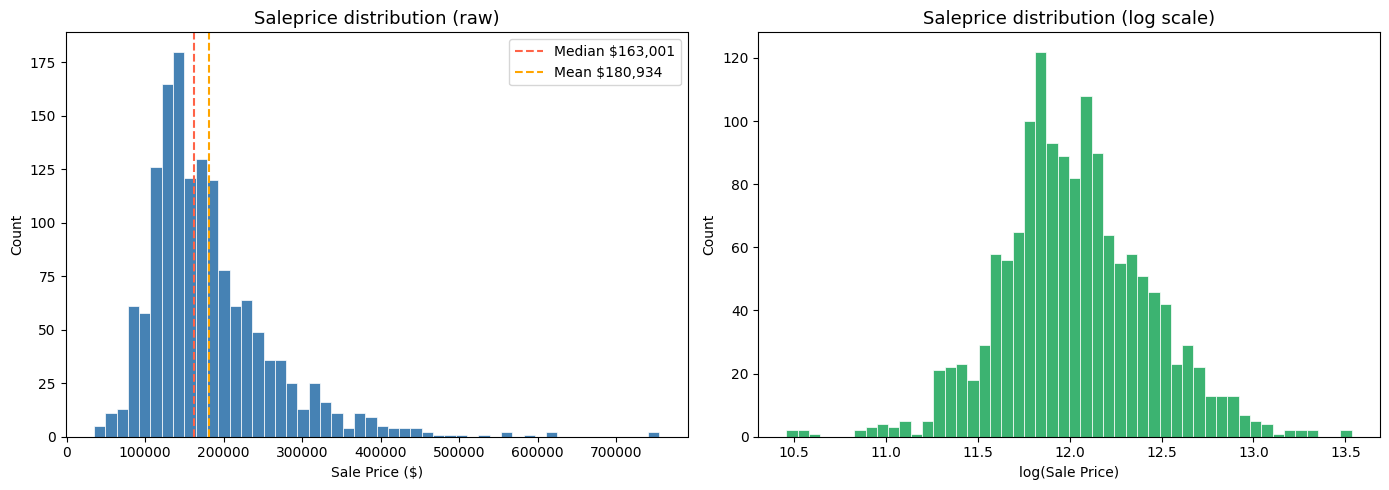

✅ Saved → ../tableau/screenshots/saleprice_distribution.png


In [32]:
# EDA: Saleprice distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Raw Saleprice
axes[0].hist(df['Saleprice'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Saleprice'].median(), color='tomato', linestyle='--', linewidth=1.5, label=f"Median ${df['Saleprice'].median():,.0f}")
axes[0].axvline(df['Saleprice'].mean(),   color='orange', linestyle='--', linewidth=1.5, label=f"Mean ${df['Saleprice'].mean():,.0f}")
axes[0].set_title('Saleprice distribution (raw)', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
axes[0].legend()
 
# Log-transformed Saleprice
axes[1].hist(np.log1p(df['Saleprice']), bins=50, color='mediumseagreen', edgecolor='white', linewidth=0.5)
axes[1].set_title('Saleprice distribution (log scale)', fontsize=13)
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Count')
 
plt.tight_layout()
plt.savefig('../tableau/screenshots/saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → ../tableau/screenshots/saleprice_distribution.png")


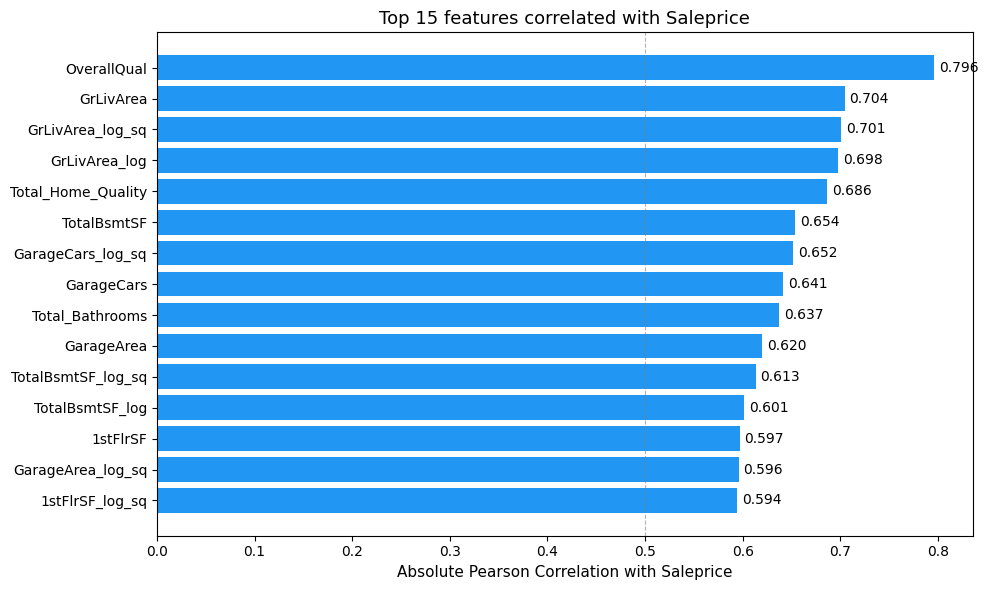

✅ Saved → ../tableau/screenshots/top15_correlations.png

Top 15 features:
               Feature  Correlation
0          OverallQual         0.80
1            GrLivArea         0.70
2     GrLivArea_log_sq         0.70
3        GrLivArea_log         0.70
4   Total_Home_Quality         0.69
5          TotalBsmtSF         0.65
6    GarageCars_log_sq         0.65
7           GarageCars         0.64
8      Total_Bathrooms         0.64
9           GarageArea         0.62
10  TotalBsmtSF_log_sq         0.61
11     TotalBsmtSF_log         0.60
12            1stFlrSF         0.60
13   GarageArea_log_sq         0.60
14     1stFlrSF_log_sq         0.59


In [33]:
# EDA: Top 15 features correlated with Saleprice
# Exclude non-feature columns
exclude = ['Id', 'Saleprice', 'is_luxury', 'is_crisis_year']
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
 
corr_with_price = (
    df[feature_cols + ['Saleprice']]
    .corr()['Saleprice']
    .drop('Saleprice')
    .abs()
    .sort_values(ascending=False)
    .head(15)
)
 
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr_with_price]
bars = ax.barh(corr_with_price.index[::-1], corr_with_price.values[::-1], color=colors[::-1])
ax.set_xlabel('Absolute Pearson Correlation with Saleprice', fontsize=11)
ax.set_title('Top 15 features correlated with Saleprice', fontsize=13)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
 
for bar, val in zip(bars, corr_with_price.values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('../tableau/screenshots/top15_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → ../tableau/screenshots/top15_correlations.png")
print("\nTop 15 features:")
print(corr_with_price.reset_index().rename(columns={'index': 'Feature', 'Saleprice': 'Correlation'}))


In [ ]:
# CELL 15 — EDA: Saleprice by OverallQual
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
 
qual_groups = [df[df['OverallQual'] == q]['Saleprice'].values
               for q in sorted(df['OverallQual'].unique())]
qual_labels = sorted(df['OverallQual'].unique())
 
bp = ax.boxplot(qual_groups, labels=qual_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5))
 
colors_qual = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(qual_labels)))
for patch, color in zip(bp['boxes'], colors_qual):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
 
ax.set_xlabel('Overall Quality Rating (1–10)', fontsize=11)
ax.set_ylabel('Sale Price ($)', fontsize=11)
ax.set_title('Sale price by Overall Quality — each point increase adds significant value', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
 
plt.tight_layout()
plt.savefig('../tableau/screenshots/price_by_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → ../tableau/screenshots/price_by_quality.png")


/var/folders/21/z21b19xd5_g1_h61mdxcdyrh0000gn/T/ipykernel_18627/2898592684.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Neighborhood'] = df[nbh_cols].idxmax(axis=1).str.replace('Neighborhood_', '')


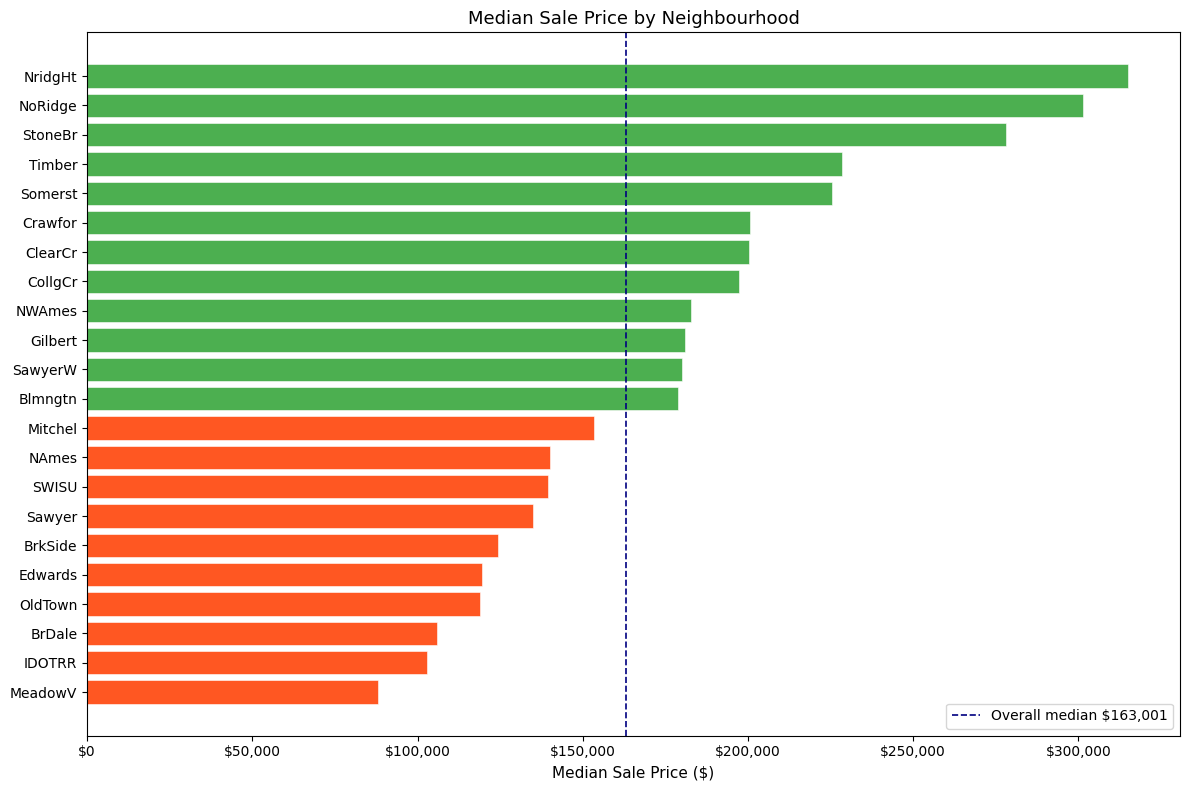

✅ Saved → ../tableau/screenshots/price_by_neighbourhood.png

Neighbourhood tiers:
  Premium  (median > $214,001) : ['Somerst', 'Timber', 'StoneBr', 'NoRidge', 'NridgHt']
  Discount (median < $129,926)  : ['MeadowV', 'IDOTRR', 'BrDale', 'OldTown', 'Edwards', 'BrkSide']


In [34]:
# EDA: Median Saleprice by Neighbourhood
# Reconstruct neighbourhood from one-hot encoded columns
nbh_cols = [c for c in df.columns if c.startswith('Neighborhood_')]
 
if nbh_cols:
    df['Neighborhood'] = df[nbh_cols].idxmax(axis=1).str.replace('Neighborhood_', '')
    nbh_price = (df.groupby('Neighborhood')['Saleprice']
                   .median()
                   .sort_values(ascending=True))
 
    fig, ax = plt.subplots(figsize=(12, 8))
    colors_nbh = ['#4CAF50' if v > df['Saleprice'].median() else '#FF5722'
                  for v in nbh_price.values]
    ax.barh(nbh_price.index, nbh_price.values, color=colors_nbh, edgecolor='white', linewidth=0.4)
    ax.axvline(df['Saleprice'].median(), color='navy', linestyle='--',
               linewidth=1.2, label=f"Overall median ${df['Saleprice'].median():,.0f}")
    ax.set_xlabel('Median Sale Price ($)', fontsize=11)
    ax.set_title('Median Sale Price by Neighbourhood', fontsize=13)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend()
 
    plt.tight_layout()
    plt.savefig('../tableau/screenshots/price_by_neighbourhood.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved → ../tableau/screenshots/price_by_neighbourhood.png")
 
    # Tier segmentation
    high_thresh = df['Saleprice'].quantile(0.75)
    low_thresh  = df['Saleprice'].quantile(0.25)
    print("\nNeighbourhood tiers:")
    print(f"  Premium  (median > ${high_thresh:,.0f}) : {nbh_price[nbh_price > high_thresh].index.tolist()}")
    print(f"  Discount (median < ${low_thresh:,.0f})  : {nbh_price[nbh_price < low_thresh].index.tolist()}")


In [ ]:
# CELL 17 — EDA: Price trend 2006–2010
# ============================================================
yr_cols = [c for c in df.columns if c.startswith('YrSold_')]
 
if yr_cols:
    df['YrSold'] = df[yr_cols].idxmax(axis=1).str.replace('YrSold_', '').astype(int)
    yr_price = df.groupby('YrSold')['Saleprice'].agg(['median', 'mean', 'count'])
 
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
 
    ax1.plot(yr_price.index, yr_price['median'], 'o-', color='steelblue',
             linewidth=2, markersize=7, label='Median price')
    ax1.plot(yr_price.index, yr_price['mean'], 's--', color='tomato',
             linewidth=1.5, markersize=6, label='Mean price')
    ax2.bar(yr_price.index, yr_price['count'], alpha=0.2, color='gray', label='Volume')
 
    ax1.set_xlabel('Year Sold')
    ax1.set_ylabel('Sale Price ($)')
    ax2.set_ylabel('Number of Sales')
    ax1.set_title('Sale Price Trend 2006–2010 (crisis dip visible in 2008–2009)', fontsize=13)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax1.legend(loc='upper left')
 
    # Shade crisis years
    ax1.axvspan(2007.5, 2009.5, alpha=0.08, color='red', label='Crisis years')
 
    plt.tight_layout()
    plt.savefig('../tableau/screenshots/price_trend_2006_2010.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved → ../tableau/screenshots/price_trend_2006_2010.png")
    print(yr_price)


In [35]:
# Statistical: Amenity uplift t-tests

from scipy.stats import ttest_ind
 
amenity_flags = {
    'hasfireplace' : 'Fireplace',
    'HasWoodDeck'  : 'Wood Deck',
    'HasOpenPorch' : 'Open Porch',
}
 
print("=" * 65)
print("AMENITY UPLIFT — t-test: mean price WITH vs WITHOUT amenity")
print("=" * 65)
print(f"{'Amenity':<20} {'With ($)':>12} {'Without ($)':>12} {'Uplift ($)':>12} {'p-value':>10} {'Sig?':>6}")
print("-" * 65)
 
for flag, label in amenity_flags.items():
    if flag not in df.columns:
        continue
    with_amenity    = df[df[flag] == 1]['Saleprice']
    without_amenity = df[df[flag] == 0]['Saleprice']
    t_stat, p_val   = ttest_ind(with_amenity, without_amenity)
    uplift          = with_amenity.mean() - without_amenity.mean()
    sig             = "✅ Yes" if p_val < 0.05 else "❌ No"
    print(f"{label:<20} {with_amenity.mean():>12,.0f} {without_amenity.mean():>12,.0f} "
          f"{uplift:>+12,.0f} {p_val:>10.4f} {sig:>6}")


AMENITY UPLIFT — t-test: mean price WITH vs WITHOUT amenity
Amenity                  With ($)  Without ($)   Uplift ($)    p-value   Sig?
-----------------------------------------------------------------
Fireplace                 216,513      141,332      +75,181     0.0000  ✅ Yes
Wood Deck                 158,267      205,682      -47,416     0.0000  ✅ Yes
Open Porch                144,615      210,641      -66,025     0.0000  ✅ Yes


In [36]:
# Statistical: Price vs OverallQual correlation

r_qual, p_qual = stats.pearsonr(df['OverallQual'], df['Saleprice'])
r_size, p_size = stats.pearsonr(df['GrLivArea'],   df['Saleprice'])
r_tot,  p_tot  = stats.pearsonr(df['TotalSF'],     df['Saleprice'])
 
print("=" * 55)
print("KEY CORRELATION RESULTS")
print("=" * 55)
print(f"  OverallQual vs Saleprice : r = {r_qual:.3f}  (p={p_qual:.2e})")
print(f"  GrLivArea   vs Saleprice : r = {r_size:.3f}  (p={p_size:.2e})")
print(f"  TotalSF     vs Saleprice : r = {r_tot:.3f}   (p={p_tot:.2e})")


KEY CORRELATION RESULTS
  OverallQual vs Saleprice : r = 0.796  (p=1.88e-319)
  GrLivArea   vs Saleprice : r = 0.704  (p=5.40e-219)
  TotalSF     vs Saleprice : r = 0.546   (p=5.11e-114)


In [37]:
# Final outputs checklist
import os
 
outputs = {
    'cleaned_data.csv'         : '../data/processed/cleaned_data.csv',
    'tableau_ready.csv'        : '../data/processed/tableau_ready.csv',
    'saleprice_distribution'   : '../tableau/screenshots/saleprice_distribution.png',
    'top15_correlations'       : '../tableau/screenshots/top15_correlations.png',
    'price_by_quality'         : '../tableau/screenshots/price_by_quality.png',
    'price_by_neighbourhood'   : '../tableau/screenshots/price_by_neighbourhood.png',
    'price_trend_2006_2010'    : '../tableau/screenshots/price_trend_2006_2010.png',
}
 
print("=" * 55)
print("OUTPUT FILES CHECKLIST")
print("=" * 55)
for name, path in outputs.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ NOT FOUND"
    size   = f"({os.path.getsize(path)/1024:.1f} KB)" if exists else ""
    print(f"  {status}  {name:<35} {size}")
 





OUTPUT FILES CHECKLIST
  ✅  cleaned_data.csv                    (2183.5 KB)
  ✅  tableau_ready.csv                   (597.6 KB)
  ✅  saleprice_distribution              (53.9 KB)
  ✅  top15_correlations                  (85.2 KB)
  ❌ NOT FOUND  price_by_quality                    
  ✅  price_by_neighbourhood              (74.7 KB)
  ❌ NOT FOUND  price_trend_2006_2010               
